# **Начало.**

In [ ]:
# Библиотеки
import torch
import torchvision
from torchvision.datasets import MNIST
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from torch.utils.data import random_split
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torch.nn as nn

In [ ]:
# Импортируем датасет
mnist_dataset = MNIST(root = 'data/', train = True, transform = transforms.ToTensor(), download=True)
print(mnist_dataset)

Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1007)>



100%|██████████| 9.91M/9.91M [00:00<00:00, 16.3MB/s]


Extracting data/MNIST/raw/train-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1007)>



100%|██████████| 28.9k/28.9k [00:00<00:00, 501kB/s]


Extracting data/MNIST/raw/train-labels-idx1-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1007)>



100%|██████████| 1.65M/1.65M [00:00<00:00, 4.51MB/s]


Extracting data/MNIST/raw/t10k-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1007)>



100%|██████████| 4.54k/4.54k [00:00<00:00, 2.69MB/s]

Extracting data/MNIST/raw/t10k-labels-idx1-ubyte.gz to data/MNIST/raw

Dataset MNIST
    Number of datapoints: 60000
    Root location: data/
    Split: Train
    StandardTransform
Transform: ToTensor()


In [ ]:
# Создаем тренировочную и валидационную выборки 84/16, по моему варианту
train_data, validation_data = random_split(mnist_dataset, [50400, 9600])

In [ ]:
# Размер батча = 10
batch_size = 10
train_loader = DataLoader(train_data, batch_size, shuffle = True)
val_loader = DataLoader(validation_data, batch_size, shuffle = False)

In [ ]:
# Создаем модель линейной регрессии
input_size = 28 * 28
num_classes = 10
model = nn.Linear(input_size, num_classes)

# **Тут немного кода для проверки модели на данных одного батча.**

In [ ]:
# Создаем модель классификации
class MnistModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(input_size, 128)
        self.linear2 = nn.Linear(128, 64)
        self.linear3 = nn.Linear(64, 32)
        self.linear4 = nn.Linear(32, 16)
        self.linear5 = nn.Linear(16, num_classes)

    def forward(self, xb):
        xb = xb.reshape(-1, 784)
        print(xb)
        out = F.relu(self.linear1(xb))
        out = F.relu(self.linear2(out))
        out = F.relu(self.linear3(out))
        out = F.relu(self.linear4(out))
        out = self.linear5(out)
        print(out)
        return out

model = MnistModel()
print(model.linear5.weight.shape, model.linear5.bias.shape)
list(model.parameters())

torch.Size([10, 16]) torch.Size([10])


[Parameter containing:
 tensor([[-0.0217, -0.0355, -0.0206,  ..., -0.0295, -0.0103,  0.0116],
         [ 0.0261,  0.0239, -0.0311,  ...,  0.0229,  0.0246, -0.0334],
         [ 0.0134,  0.0063, -0.0061,  ...,  0.0254,  0.0306,  0.0150],
         ...,
         [ 0.0125, -0.0119, -0.0127,  ...,  0.0140, -0.0016, -0.0314],
         [ 0.0329,  0.0219,  0.0304,  ...,  0.0179, -0.0151, -0.0302],
         [-0.0020,  0.0202,  0.0322,  ...,  0.0182,  0.0289, -0.0292]],
        requires_grad=True),
 Parameter containing:
 tensor([-1.9719e-02,  1.1530e-02, -1.8236e-02, -1.9416e-02, -9.1929e-03,
          2.6193e-02, -5.5298e-03,  2.7855e-02,  1.7832e-02, -1.6255e-02,
         -1.4808e-02,  1.8597e-02,  1.3173e-02, -2.0898e-02, -1.4874e-02,
          9.0237e-03,  4.0366e-03,  2.2809e-03,  3.2690e-02, -3.2306e-02,
          6.8551e-03, -2.4978e-02,  1.1607e-02, -3.3130e-02,  1.0200e-02,
         -8.4092e-03,  8.7870e-03,  1.1657e-02, -3.4364e-02, -2.6523e-02,
         -5.5790e-03, -3.3576e-02,  3.51

In [ ]:
for images, labels in train_loader:
    outputs = model(images)
    break

print('outputs shape: ', outputs.shape)
print('Sample outputs: \n', outputs[:2].data)

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
tensor([[ 0.1992, -0.0691, -0.0143,  0.0810,  0.0114,  0.2005, -0.0338, -0.1517,
         -0.2364, -0.0087],
        [ 0.2013, -0.0694, -0.0128,  0.0804,  0.0109,  0.1983, -0.0312, -0.1504,
         -0.2376, -0.0071],
        [ 0.2016, -0.0710, -0.0120,  0.0806,  0.0140,  0.1991, -0.0326, -0.1511,
         -0.2361, -0.0105],
        [ 0.2035, -0.0699, -0.0124,  0.0804,  0.0118,  0.1957, -0.0296, -0.1502,
         -0.2380, -0.0075],
        [ 0.1988, -0.0709, -0.0134,  0.0792,  0.0090,  0.1989, -0.0322, -0.1514,
         -0.2359, -0.0118],
        [ 0.2032, -0.0702, -0.0136,  0.0804,  0.0144,  0.1962, -0.0299, -0.1521,
         -0.2378, -0.0078],
        [ 0.2010, -0.0702, -0.0157,  0.0802,  0.0158,  0.1987, -0.0326, -0.1501,
         -0

In [ ]:
probs = F.softmax(outputs, dim = 1)

## chaecking at sample probabilities
print("Sample probabilities:\n", probs[:2].data)

print("\n")
## Add up the probabilities of an output row
print("Sum: ", torch.sum(probs[0]).item())
max_probs, preds = torch.max(probs, dim = 1)
print("\n")
print(preds)
print("\n")
print(max_probs)

Sample probabilities:
 tensor([[0.1213, 0.0927, 0.0980, 0.1077, 0.1005, 0.1214, 0.0961, 0.0854, 0.0784,
         0.0985],
        [0.1215, 0.0927, 0.0981, 0.1076, 0.1004, 0.1211, 0.0963, 0.0855, 0.0783,
         0.0986]])


Sum:  1.0000001192092896


tensor([5, 0, 0, 0, 5, 0, 0, 0, 5, 0])


tensor([0.1214, 0.1215, 0.1215, 0.1217, 0.1213, 0.1217, 0.1215, 0.1218, 0.1215,
        0.1214], grad_fn=<MaxBackward0>)


In [ ]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim = 1)
    return(torch.tensor(torch.sum(preds == labels).item()/ len(preds)))

print("Accuracy: ",accuracy(outputs, labels))
print("\n")
loss_fn = F.cross_entropy
print("Loss Function: ",loss_fn)
print("\n")
## Loss for the current batch
loss = loss_fn(outputs, labels)
print(loss.item())

Accuracy:  tensor(0.1000)


Loss Function:  <function cross_entropy at 0x7dfe08c47910>


2.3373043537139893


# **Тут уже сама модель.**

In [ ]:
# Модель с пятью линейными слоями.
class MnistModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(input_size, 128)
        self.linear2 = nn.Linear(128, 64)
        self.linear3 = nn.Linear(64, 32)
        self.linear4 = nn.Linear(32, 16)
        self.linear5 = nn.Linear(16, num_classes)

    def forward(self, xb):
        xb = xb.reshape(-1, 784)
        out = F.relu(self.linear1(xb))
        out = F.relu(self.linear2(out))
        out = F.relu(self.linear3(out))
        out = F.relu(self.linear4(out))
        out = self.linear5(out)
        return out

    def training_step(self, batch):
        images, labels = batch
        out = self(images) ## Generate predictions
        loss = F.cross_entropy(out, labels) ## Calculate the loss
        return loss

    def validation_step(self, batch):
        images, labels = batch
        out = self(images)
        loss = F.cross_entropy(out, labels)
        acc = accuracy(out, labels)
        return {'val_loss':loss, 'val_acc': acc}

    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()
        return {'val_loss': epoch_loss.item(), 'val_acc' : epoch_acc.item()}

    def epoch_end(self, epoch,result):
        print("Epoch [{}], val_loss: {:.4f}, val_acc: {:.4f}".format(epoch, result['val_loss'], result['val_acc']))

model = MnistModel()

In [ ]:
# Определяем функции для обучения модели по эпохам, для оценки модели.
def evaluate(model, val_loader):
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

def fit(epochs, lr, model, train_loader, val_loader, opt_func = torch.optim.SGD):
    history = []
    optimizer = opt_func(model.parameters(), lr)
    for epoch in range(epochs):
        for batch in train_loader:
            optimizer.zero_grad()
            loss = model.training_step(batch)
            loss.backward()
            optimizer.step()

        result = evaluate(model, val_loader)
        model.epoch_end(epoch, result)
        history.append(result)
    return history

In [ ]:
history = fit(5, 0.001, model, train_loader, val_loader)

Epoch [0], val_loss: 0.6331, val_acc: 0.8113
Epoch [1], val_loss: 0.5445, val_acc: 0.8403
Epoch [2], val_loss: 0.4779, val_acc: 0.8606
Epoch [3], val_loss: 0.4162, val_acc: 0.8802
Epoch [4], val_loss: 0.3652, val_acc: 0.8949


Text(0.5, 1.0, 'Accuracy Vs. No. of epochs')

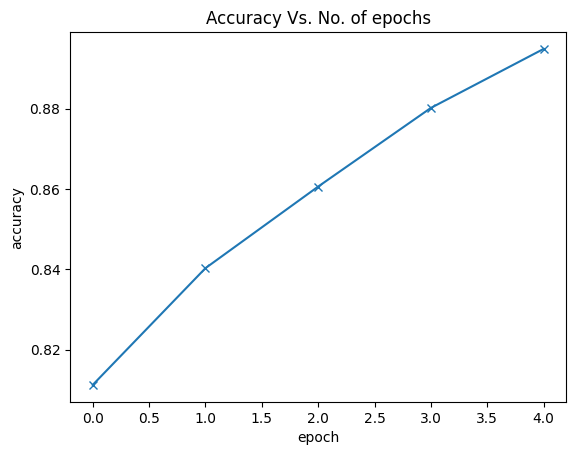

In [ ]:
# Точность модели по эпохам
accuracies = [result['val_acc'] for result in history]
plt.plot(accuracies, '-x')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('Accuracy Vs. No. of epochs')

Text(0.5, 1.0, 'Loss Vs. No. of epochs')

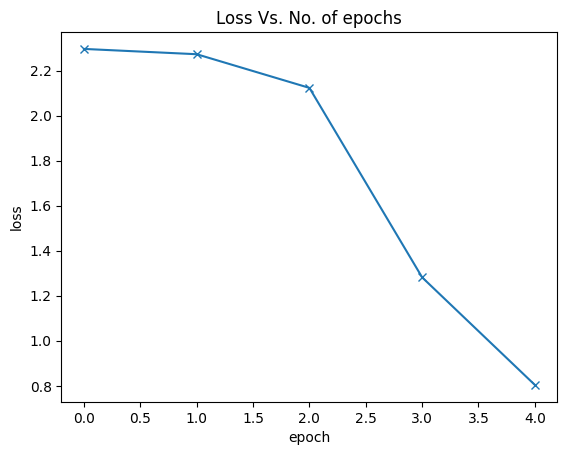

In [ ]:
# Ошибки модели по эпохам
losses = [result['val_loss'] for result in history]
plt.plot(losses, '-x')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Loss Vs. No. of epochs')

# Test

In [ ]:
test_dataset = MNIST(root = 'data/', train = False, transform = transforms.ToTensor())

shape:  torch.Size([1, 28, 28])
Label:  7


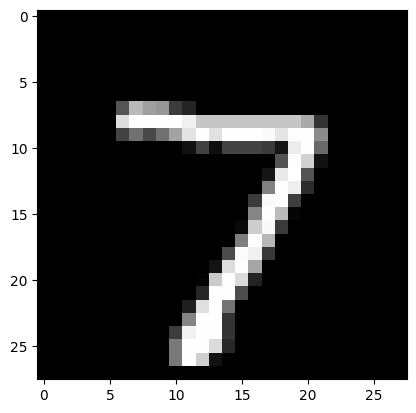

In [ ]:
img, label = test_dataset[0]
plt.imshow(img[0], cmap = 'gray')
print("shape: ", img.shape)
print('Label: ', label)

In [ ]:
print(img.unsqueeze(0).shape)
print(img.shape)

torch.Size([1, 1, 28, 28])
torch.Size([1, 28, 28])


In [ ]:
def predict_image(img, model):
    xb = img.unsqueeze(0)
    yb = model(xb)
    _, preds = torch.max(yb, dim = 1)
    return(preds[0].item())

Label: 8 , Predicted : 9


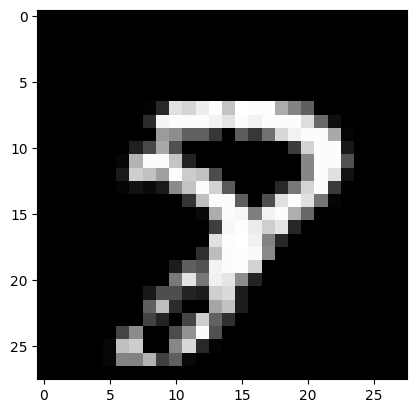

In [ ]:
img, label = test_dataset[6555]
plt.imshow(img[0], cmap = 'gray')
print('Label:', label, ', Predicted :', predict_image(img, model))

In [ ]:
torch.save(model.state_dict(), 'mnist-logistic.pth')